# Expression Decoder
Trains an MLP: **(AlphaGenome binned track, scVI cell type embedding) → scalar gene expression**

In [1]:
!pip install -q pandas pyarrow

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## Configuration

In [4]:
ORGANS = ['heart', 'lung']
ASSAY  = '10X'
ROOT   = '/content/drive/MyDrive'

TARGET_BINS   = 1024
HIDDEN_DIMS   = [64, 32]
WEIGHT_DECAY  = 1e-4
DROPOUT       = 0.1
LEARNING_RATE = 1e-3
BATCH_SIZE    = 512
EPOCHS        = 30
VAL_SPLIT     = 0.3

## Load Data

In [5]:
# Load each organ's AlphaGenome features and scVI embeddings,
# keeping only cell types that had CL-level AlphaGenome support (not UBERON fallback).
organ_data = {}
for organ in ORGANS:
    ag = np.load(f'{ROOT}/{organ}_{ASSAY}_alphagenome_features.npz', allow_pickle=True)
    cell_type_ids  = ag['cell_type_ids']
    ontology_terms = ag['ontology_terms']

    # cell type has CL support when AlphaGenome used its own CL term, not the organ UBERON fallback
    cl_mask = np.array([ot == ct for ot, ct in zip(ontology_terms, cell_type_ids)])
    if cl_mask.sum() == 0:
        raise ValueError(f'{organ}: no cell types have CL-level AlphaGenome support — check ontology mapping')
    print(f'{organ}: {cl_mask.sum()}/{len(cl_mask)} cell types have CL support — dropping {(~cl_mask).sum()} UBERON fallbacks')

    cell_type_ids = cell_type_ids[cl_mask]

    scvi_df = pd.read_parquet(f'{ROOT}/{organ}_{ASSAY}_cell_type_embeds.parquet')
    scvi_cols = [c for c in scvi_df.columns if c.startswith('scvi_')]

    # Bin 8192 → TARGET_BINS by mean-pooling, then filter to CL cell types
    raw = ag['features'][cl_mask]
    if raw.shape[2] != TARGET_BINS:
        factor = raw.shape[2] // TARGET_BINS
        raw = raw.reshape(*raw.shape[:2], TARGET_BINS, factor).mean(axis=-1).astype(np.float32)

    organ_data[organ] = {
        'features':  raw,
        'labels':    ag['labels'][cl_mask].astype(np.float32),
        'gene_ids':  ag['gene_ids'],
        'scvi':      scvi_df.loc[cell_type_ids, scvi_cols].values.astype(np.float32),
        'n_ct':      int(cl_mask.sum()),
    }
    print(f'  features={raw.shape}')

n_bins   = next(iter(organ_data.values()))['features'].shape[2]
scvi_dim = next(iter(organ_data.values()))['scvi'].shape[1]
print(f'\nn_bins={n_bins}  scvi_dim={scvi_dim}')

heart: 4/15 cell types have CL support — dropping 11 UBERON fallbacks
  features=(4, 10000, 1024)
lung: 6/29 cell types have CL support — dropping 23 UBERON fallbacks
  features=(6, 10000, 1024)

n_bins=1024  scvi_dim=50


## Dataset
Each sample is a **(cell type, gene)** pair. Train/val split on **genes** to avoid leaking genomic context.

In [6]:
# Split on gene_id strings so the same gene is in the same split across all organs
all_gene_ids = sorted(set(gid for d in organ_data.values() for gid in d['gene_ids']))
rng          = np.random.default_rng(42)
shuffled     = rng.permutation(all_gene_ids)
split        = int(len(shuffled) * (1 - VAL_SPLIT))
train_gene_set, val_gene_set = set(shuffled[:split]), set(shuffled[split:])

# Fit sequence scaler on training features across all organs, then normalize each organ
seq_scaler = StandardScaler().fit(np.concatenate([
    d['features'][:, [i for i, g in enumerate(d['gene_ids']) if g in train_gene_set], :].reshape(-1, n_bins)
    for d in organ_data.values()
]))
scvi_scaler = StandardScaler().fit(np.concatenate([d['scvi'] for d in organ_data.values()]))

for d in organ_data.values():
    n_ct, n_genes = d['features'].shape[:2]
    d['features_norm'] = seq_scaler.transform(d['features'].reshape(-1, n_bins)).reshape(n_ct, n_genes, n_bins).astype(np.float32)
    d['scvi_norm']     = scvi_scaler.transform(d['scvi']).astype(np.float32)

class ExpressionDataset(Dataset):
    def __init__(self, gene_set):
        self.samples = [
            (organ, ct, g_idx)
            for organ, d in organ_data.items()
            for g_idx, g_id in enumerate(d['gene_ids']) if g_id in gene_set
            for ct in range(d['n_ct'])
        ]
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        organ, ct, g = self.samples[idx]
        d = organ_data[organ]
        x_seq  = torch.tensor(d['features_norm'][ct, g])   # [n_bins]
        x_scvi = torch.tensor(d['scvi_norm'][ct])          # [scvi_dim]
        y = torch.tensor(d['labels'][ct, g], dtype=torch.float32)
        return x_seq, x_scvi, y

train_loader = DataLoader(ExpressionDataset(train_gene_set), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(ExpressionDataset(val_gene_set),   batch_size=BATCH_SIZE)
print(f'Train: {len(train_loader.dataset):,}  Val: {len(val_loader.dataset):,}')

Train: 70,000  Val: 30,000


## Model

In [8]:
class ExpressionDecoder(nn.Module):
    def __init__(self, scvi_dim, hidden_dims, dropout):
        super().__init__()
        # 1D CNN over the binned track: learns local signal patterns regardless of position
        self.cnn = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=8, stride=4),   # [B, 32, 31]
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=4, stride=2),  # [B, 64, 14]
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),                     # [B, 64, 1]
        )
        dims = [64 + scvi_dim] + hidden_dims
        layers = [l for i in range(len(dims)-1) for l in (nn.Linear(dims[i], dims[i+1]), nn.ReLU(), nn.Dropout(dropout))]
        layers.append(nn.Linear(hidden_dims[-1], 1))
        self.mlp = nn.Sequential(*layers)

    def forward(self, x_seq, x_scvi):
        cnn_out = self.cnn(x_seq.unsqueeze(1)).squeeze(-1)  # [B, 64]
        x = torch.cat([cnn_out, x_scvi], dim=1)
        return self.mlp(x).squeeze(-1)

model = ExpressionDecoder(scvi_dim, HIDDEN_DIMS, DROPOUT).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f'Model params: {n_params:,}')

Model params: 18,017


In [9]:
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
loss_fn   = nn.MSELoss()
train_losses, val_losses, val_rs = [], [], []

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss = 0
    for x_seq, x_scvi, y in train_loader:
        x_seq, x_scvi, y = x_seq.to(device), x_scvi.to(device), y.to(device)
        optimizer.zero_grad()
        loss = loss_fn(model(x_seq, x_scvi), y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(y)
    train_loss /= len(train_loader.dataset)

    model.eval()
    val_preds, val_labels = [], []
    with torch.no_grad():
        for xs, xv, y in val_loader:
            val_preds.append(model(xs.to(device), xv.to(device)).cpu().numpy())
            val_labels.append(y.numpy())
    val_preds  = np.concatenate(val_preds)
    val_labels = np.concatenate(val_labels)
    val_loss = float(np.mean((val_preds - val_labels) ** 2))
    val_r    = float(pearsonr(val_preds, val_labels)[0])

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_rs.append(val_r)
    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:>3}/{EPOCHS}  train={train_loss:.4f}  val_mse={val_loss:.4f}  val_r={val_r:.4f}')

Epoch   1/30  train=4.0240  val_mse=3.3124  val_r=0.0570
Epoch   5/30  train=2.9567  val_mse=2.9637  val_r=0.3333
Epoch  10/30  train=2.1219  val_mse=2.0476  val_r=0.6220
Epoch  15/30  train=1.9402  val_mse=2.0623  val_r=0.6426
Epoch  20/30  train=1.9078  val_mse=2.2146  val_r=0.6441
Epoch  25/30  train=1.8693  val_mse=1.9463  val_r=0.6454
Epoch  30/30  train=1.8164  val_mse=1.9197  val_r=0.6521


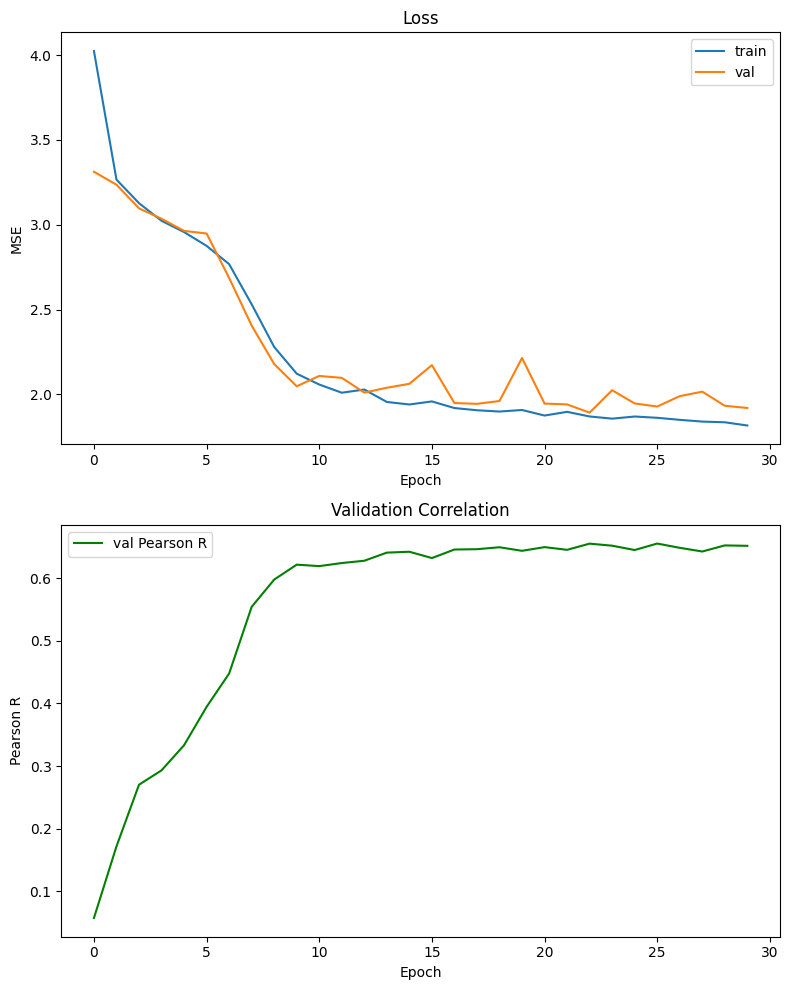

In [10]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10))
ax1.plot(train_losses, label='train'); ax1.plot(val_losses, label='val')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('MSE'); ax1.legend(); ax1.set_title('Loss')
ax2.plot(val_rs, label='val Pearson R', color='green')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Pearson R'); ax2.legend(); ax2.set_title('Validation Correlation')
plt.tight_layout(); plt.show()

## Ablation Study

In [11]:
class ScviOnlyDecoder(nn.Module):
    """MLP over scVI embedding only — no sequence features."""
    def __init__(self, scvi_dim, hidden_dims, dropout):
        super().__init__()
        dims = [scvi_dim] + hidden_dims
        layers = [l for i in range(len(dims)-1) for l in (nn.Linear(dims[i], dims[i+1]), nn.ReLU(), nn.Dropout(dropout))]
        layers.append(nn.Linear(hidden_dims[-1], 1))
        self.net = nn.Sequential(*layers)
    def forward(self, x_seq, x_scvi):
        return self.net(x_scvi).squeeze(-1)

class SeqOnlyDecoder(nn.Module):
    """1D CNN over AlphaGenome track only — no scVI embedding."""
    def __init__(self, hidden_dims, dropout):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=8, stride=4),
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=4, stride=2),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        dims = [64] + hidden_dims
        layers = [l for i in range(len(dims)-1) for l in (nn.Linear(dims[i], dims[i+1]), nn.ReLU(), nn.Dropout(dropout))]
        layers.append(nn.Linear(hidden_dims[-1], 1))
        self.mlp = nn.Sequential(*layers)
    def forward(self, x_seq, x_scvi):
        return self.mlp(self.cnn(x_seq.unsqueeze(1)).squeeze(-1)).squeeze(-1)

def run_training(m, label):
    opt = torch.optim.Adam(m.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    t_losses, v_losses, v_rs = [], [], []
    for epoch in range(1, EPOCHS + 1):
        m.train()
        t_loss = 0
        for xs, xv, y in train_loader:
            xs, xv, y = xs.to(device), xv.to(device), y.to(device)
            opt.zero_grad()
            l = loss_fn(m(xs, xv), y)
            l.backward()
            opt.step()
            t_loss += l.item() * len(y)
        t_loss /= len(train_loader.dataset)
        m.eval()
        preds, labs = [], []
        with torch.no_grad():
            for xs, xv, y in val_loader:
                preds.append(m(xs.to(device), xv.to(device)).cpu().numpy())
                labs.append(y.numpy())
        preds = np.concatenate(preds); labs = np.concatenate(labs)
        v_loss = float(np.mean((preds - labs) ** 2))
        v_r    = float(pearsonr(preds, labs)[0])
        t_losses.append(t_loss); v_losses.append(v_loss); v_rs.append(v_r)
        if epoch % 5 == 0 or epoch == 1:
            print(f'[{label}] Epoch {epoch:>3}/{EPOCHS}  train={t_loss:.4f}  val_mse={v_loss:.4f}  val_r={v_r:.4f}')
    return t_losses, v_losses, v_rs

In [12]:
print('=== scVI-only baseline ===')
scvi_model = ScviOnlyDecoder(scvi_dim, HIDDEN_DIMS, DROPOUT).to(device)
scvi_t_losses, scvi_v_losses, scvi_v_rs = run_training(scvi_model, 'scVI-only')

print('\n=== AlphaGenome-only baseline ===')
seq_model = SeqOnlyDecoder(HIDDEN_DIMS, DROPOUT).to(device)
seq_t_losses, seq_v_losses, seq_v_rs = run_training(seq_model, 'AlphaGenome-only')

=== scVI-only baseline ===
[scVI-only] Epoch   1/30  train=4.5656  val_mse=3.3157  val_r=0.0421
[scVI-only] Epoch   5/30  train=3.2908  val_mse=3.3085  val_r=0.0524
[scVI-only] Epoch  10/30  train=3.2800  val_mse=3.3079  val_r=0.0602
[scVI-only] Epoch  15/30  train=3.2803  val_mse=3.3180  val_r=0.0461
[scVI-only] Epoch  20/30  train=3.2690  val_mse=3.3242  val_r=0.0488
[scVI-only] Epoch  25/30  train=3.2617  val_mse=3.3164  val_r=0.0486
[scVI-only] Epoch  30/30  train=3.2566  val_mse=3.3169  val_r=0.0503

=== AlphaGenome-only baseline ===
[AlphaGenome-only] Epoch   1/30  train=4.5501  val_mse=3.4077  val_r=-0.0598
[AlphaGenome-only] Epoch   5/30  train=3.0811  val_mse=3.1270  val_r=0.2425
[AlphaGenome-only] Epoch  10/30  train=3.0008  val_mse=3.0272  val_r=0.3144
[AlphaGenome-only] Epoch  15/30  train=2.8479  val_mse=3.0427  val_r=0.3736
[AlphaGenome-only] Epoch  20/30  train=2.6366  val_mse=2.6965  val_r=0.4405
[AlphaGenome-only] Epoch  25/30  train=2.4379  val_mse=2.4863  val_r=0.529

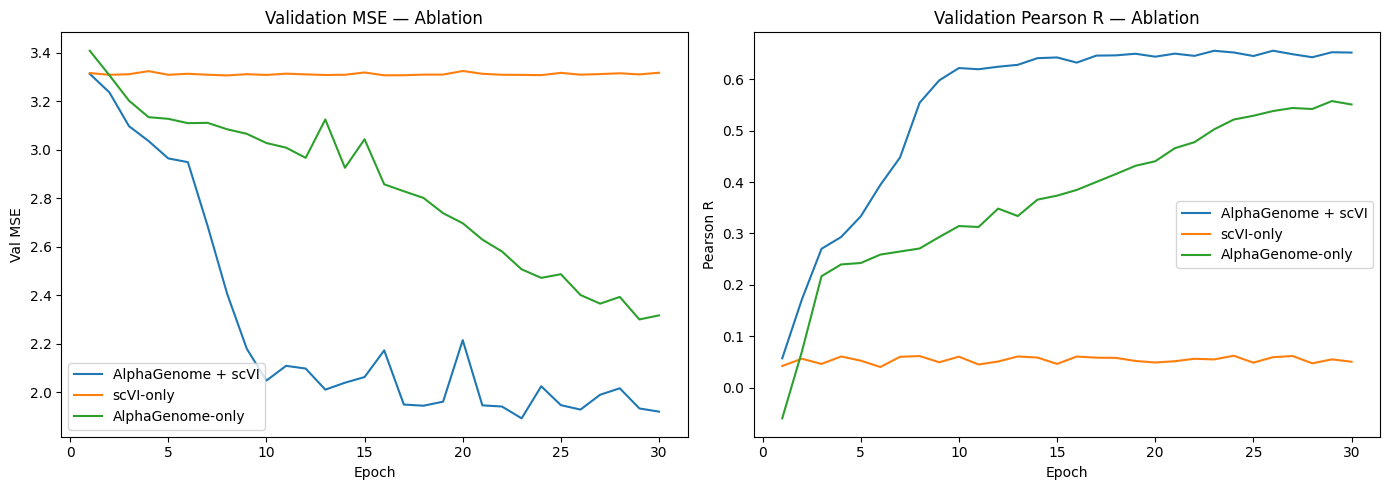


Final val_r  —  AlphaGenome+scVI: 0.6521  |  scVI-only: 0.0503  |  AlphaGenome-only: 0.5510


In [13]:
epochs = range(1, EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs, val_losses,      label='AlphaGenome + scVI')
ax1.plot(epochs, scvi_v_losses,   label='scVI-only')
ax1.plot(epochs, seq_v_losses,    label='AlphaGenome-only')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Val MSE'); ax1.legend(); ax1.set_title('Validation MSE — Ablation')

ax2.plot(epochs, val_rs,          label='AlphaGenome + scVI')
ax2.plot(epochs, scvi_v_rs,       label='scVI-only')
ax2.plot(epochs, seq_v_rs,        label='AlphaGenome-only')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Pearson R'); ax2.legend(); ax2.set_title('Validation Pearson R — Ablation')

plt.tight_layout(); plt.show()
print(f'\nFinal val_r  —  AlphaGenome+scVI: {val_rs[-1]:.4f}  |  scVI-only: {scvi_v_rs[-1]:.4f}  |  AlphaGenome-only: {seq_v_rs[-1]:.4f}')

## Bin Size Sweep
Trains the multimodal model (AlphaGenome CNN + scVI) at each bin resolution to find the best trade-off between resolution and overfitting. All sizes are powers of 2 that divide 8192 (the raw encoder resolution).

In [14]:
import gc

# Powers of 2 that divide 8192; 4096 is the practical upper limit before memory pressure
BIN_SIZES = [64, 128, 256, 512, 1024, 2048, 4096]

def make_loaders_for_bins(target_bins):
    """Reload raw features from disk, bin to target_bins, scale, return (train_loader, val_loader, scvi_dim)."""
    data = {}
    for organ in ORGANS:
        ag  = np.load(f'{ROOT}/{organ}_{ASSAY}_alphagenome_features.npz', allow_pickle=True)
        ct_ids = ag['cell_type_ids']
        cl_mask = np.array([ot == ct for ot, ct in zip(ag['ontology_terms'], ct_ids)])
        ct_ids  = ct_ids[cl_mask]

        scvi_df   = pd.read_parquet(f'{ROOT}/{organ}_{ASSAY}_cell_type_embeds.parquet')
        scvi_cols = [c for c in scvi_df.columns if c.startswith('scvi_')]

        raw    = ag['features'][cl_mask].astype(np.float32)
        factor = raw.shape[2] // target_bins
        raw    = raw.reshape(*raw.shape[:2], target_bins, factor).mean(axis=-1)

        data[organ] = {
            'features': raw,
            'labels':   ag['labels'][cl_mask].astype(np.float32),
            'gene_ids': ag['gene_ids'],
            'scvi':     scvi_df.loc[ct_ids, scvi_cols].values.astype(np.float32),
            'n_ct':     int(cl_mask.sum()),
        }

    # Fit scalers on training genes only
    sq_sc = StandardScaler().fit(np.concatenate([
        data[o]['features'][:, [i for i, g in enumerate(data[o]['gene_ids']) if g in train_gene_set], :]
        .reshape(-1, target_bins) for o in ORGANS
    ]))
    sv_sc = StandardScaler().fit(np.concatenate([data[o]['scvi'] for o in ORGANS]))

    for d in data.values():
        nc, ng = d['features'].shape[:2]
        d['fn'] = sq_sc.transform(d['features'].reshape(-1, target_bins)).reshape(nc, ng, target_bins).astype(np.float32)
        d['sn'] = sv_sc.transform(d['scvi']).astype(np.float32)

    class _DS(Dataset):
        def __init__(self, gene_set):
            self.s = [(o, ct, gi) for o in ORGANS
                      for gi, gid in enumerate(data[o]['gene_ids']) if gid in gene_set
                      for ct in range(data[o]['n_ct'])]
        def __len__(self): return len(self.s)
        def __getitem__(self, i):
            o, ct, g = self.s[i]
            return (torch.tensor(data[o]['fn'][ct, g]),
                    torch.tensor(data[o]['sn'][ct]),
                    torch.tensor(data[o]['labels'][ct, g], dtype=torch.float32))

    tr = DataLoader(_DS(train_gene_set), batch_size=BATCH_SIZE, shuffle=True)
    vl = DataLoader(_DS(val_gene_set),   batch_size=BATCH_SIZE)
    sd = next(iter(data.values()))['scvi'].shape[1]
    return tr, vl, sd

In [15]:
sweep_val_rs   = {}
sweep_val_mses = {}

for bins in BIN_SIZES:
    print(f'\n{"="*40}\nbins={bins}  (~{bins*1024//1000}kb/bin)\n{"="*40}')
    tr_l, val_l, sd = make_loaders_for_bins(bins)
    m   = ExpressionDecoder(sd, HIDDEN_DIMS, DROPOUT).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    v_rs, v_mses = [], []

    for epoch in range(1, EPOCHS + 1):
        m.train()
        for xs, xv, y in tr_l:
            xs, xv, y = xs.to(device), xv.to(device), y.to(device)
            opt.zero_grad()
            l = loss_fn(m(xs, xv), y)
            l.backward()
            opt.step()

        m.eval()
        preds, labs = [], []
        with torch.no_grad():
            for xs, xv, y in val_l:
                preds.append(m(xs.to(device), xv.to(device)).cpu().numpy())
                labs.append(y.numpy())
        preds = np.concatenate(preds); labs = np.concatenate(labs)
        v_rs.append(float(pearsonr(preds, labs)[0]))
        v_mses.append(float(np.mean((preds - labs) ** 2)))
        if epoch % 10 == 0 or epoch == EPOCHS:
            print(f'  Epoch {epoch:>3}/{EPOCHS}  val_mse={v_mses[-1]:.4f}  val_r={v_rs[-1]:.4f}')

    sweep_val_rs[bins]   = v_rs
    sweep_val_mses[bins] = v_mses

    # Free GPU and CPU memory before next bin size
    del m, opt, tr_l, val_l, preds, labs
    torch.cuda.empty_cache(); gc.collect()

print('\nSweep complete.')


bins=64  (~65kb/bin)
  Epoch  10/30  val_mse=2.0354  val_r=0.6219
  Epoch  20/30  val_mse=1.9710  val_r=0.6374
  Epoch  30/30  val_mse=1.9738  val_r=0.6438

bins=128  (~131kb/bin)
  Epoch  10/30  val_mse=2.0971  val_r=0.6155
  Epoch  20/30  val_mse=1.9968  val_r=0.6334
  Epoch  30/30  val_mse=1.9643  val_r=0.6430

bins=256  (~262kb/bin)
  Epoch  10/30  val_mse=2.0005  val_r=0.6326
  Epoch  20/30  val_mse=1.8723  val_r=0.6602
  Epoch  30/30  val_mse=1.8588  val_r=0.6633

bins=512  (~524kb/bin)
  Epoch  10/30  val_mse=2.0006  val_r=0.6373
  Epoch  20/30  val_mse=1.9246  val_r=0.6494
  Epoch  30/30  val_mse=1.9420  val_r=0.6529

bins=1024  (~1048kb/bin)
  Epoch  10/30  val_mse=2.0088  val_r=0.6293
  Epoch  10/30  val_mse=3.0309  val_r=0.3034
  Epoch  20/30  val_mse=2.8279  val_r=0.4173
  Epoch  30/30  val_mse=2.4382  val_r=0.5327

Sweep complete.


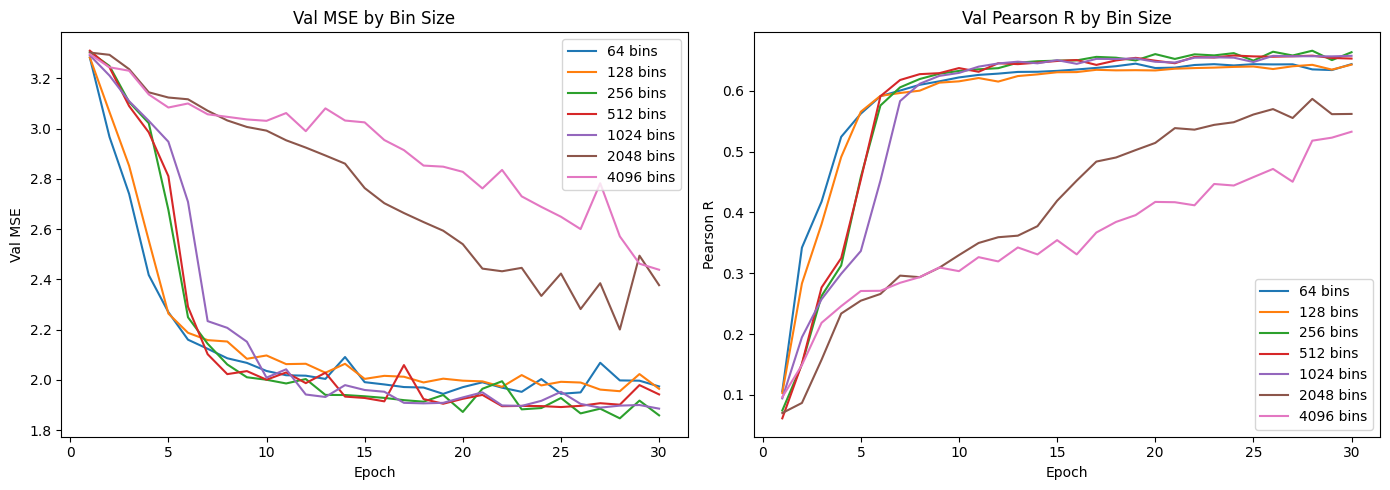


Final val_r by bin size:
     64 bins: 0.6438
    128 bins: 0.6430
    256 bins: 0.6633
    512 bins: 0.6529
   1024 bins: 0.6575
   2048 bins: 0.5619
   4096 bins: 0.5327


In [16]:
epochs = range(1, EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for bins in BIN_SIZES:
    ax1.plot(epochs, sweep_val_mses[bins], label=f'{bins} bins')
    ax2.plot(epochs, sweep_val_rs[bins],   label=f'{bins} bins')

ax1.set_xlabel('Epoch'); ax1.set_ylabel('Val MSE');    ax1.legend(); ax1.set_title('Val MSE by Bin Size')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Pearson R');  ax2.legend(); ax2.set_title('Val Pearson R by Bin Size')
plt.tight_layout(); plt.show()

print('\nFinal val_r by bin size:')
for bins in BIN_SIZES:
    print(f'  {bins:>5} bins: {sweep_val_rs[bins][-1]:.4f}')